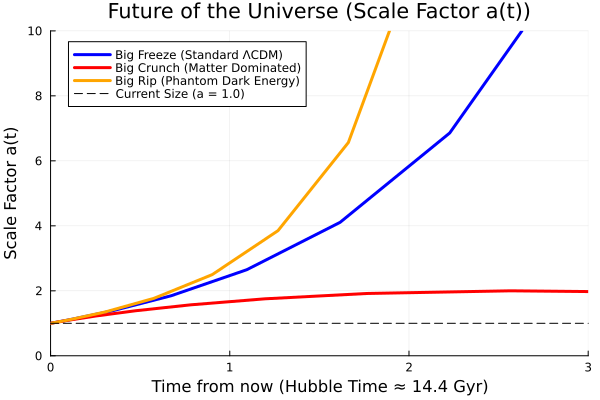

In [1]:
using DifferentialEquations, Plots

# --- 1. 物理モデル（フリードマン加速方程式） ---
function friedmann_acceleration!(du, u, p, t)
    # u[1]: スケールファクター (a)
    # u[2]: 膨張速度 (da/dt)
    a, da_dt = u
    Ω_m, Ω_de, w = p # 物質密度, DE密度, 状態方程式パラメータ

    du[1] = da_dt
    # フリードマンの第2方程式（重力とダークエネルギーの綱引き）
    # 時間単位は「ハッブル時間（約144億年）」とする
    du[2] = -0.5 * a * (Ω_m * a^(-3) + (1 + 3w) * Ω_de * a^(-3*(1+w)))
end

# 現在の宇宙の初期条件
a0 = 1.0  # 現在の宇宙の大きさ
v0 = 1.0  # 現在の膨張速度 (無次元化)
u0 = [a0, v0]
tspan = (0.0, 3.0) # 現在から約430億年後までシミュレーション

# --- 2. 3つの宇宙の終焉パターンのパラメータ ---
# パラメータ構成: [Ω_m(物質), Ω_de(ダークエネルギー), w(DEの性質)]

# パターン1: Big Freeze (現在の標準宇宙論・ΛCDMモデル)
params_freeze = [0.3, 0.7, -1.0]

# パターン2: Big Crunch (物質が過剰で、重力が勝つ宇宙)
params_crunch = [2.0, 0.0, 0.0]

# パターン3: Big Rip (ファントム・ダークエネルギーが暴走する宇宙)
params_rip = [0.3, 0.7, -1.2]

# --- 3. 微分方程式の求解 ---
# 特異点（a=0 または a=∞）に達した時点で計算をストップする設定
cond_crunch(u, t, int) = u[1] - 0.001 # aが0になったら停止
affect!(int) = terminate!(int)
cond_rip(u, t, int) = u[1] - 100.0 # aが100倍になったら停止
cb = CallbackSet(ContinuousCallback(cond_crunch, affect!), ContinuousCallback(cond_rip, affect!))

prob_freeze = ODEProblem(friedmann_acceleration!, u0, tspan, params_freeze)
sol_freeze = solve(prob_freeze, Tsit5(), callback=cb)

prob_crunch = ODEProblem(friedmann_acceleration!, u0, tspan, params_crunch)
sol_crunch = solve(prob_crunch, Tsit5(), callback=cb)

prob_rip = ODEProblem(friedmann_acceleration!, u0, tspan, params_rip)
sol_rip = solve(prob_rip, Tsit5(), callback=cb)

# --- 4. グラフの描画 ---
plot(sol_freeze.t, [u[1] for u in sol_freeze.u], 
    label="Big Freeze (Standard ΛCDM)", color=:blue, linewidth=3,
    title="Future of the Universe (Scale Factor a(t))",
    xlabel="Time from now (Hubble Time ≈ 14.4 Gyr)", ylabel="Scale Factor a(t)",
    xlim=(0, 3), ylim=(0, 10), grid=true, legend=:topleft)

plot!(sol_crunch.t, [u[1] for u in sol_crunch.u], 
    label="Big Crunch (Matter Dominated)", color=:red, linewidth=3)

plot!(sol_rip.t, [u[1] for u in sol_rip.u], 
    label="Big Rip (Phantom Dark Energy)", color=:orange, linewidth=3)

# 現在のサイズを示す基準線
hline!([1.0], color=:black, linestyle=:dash, label="Current Size (a = 1.0)")